In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("../data/Encoding_data.csv")

In [24]:
# Numerical columns
num_cols = df.select_dtypes(
    include=['int64', 'float64']
).columns

print("Numerical Columns:")
print(num_cols)

Numerical Columns:
Index(['Unnamed: 0.1', 'Unnamed: 0', 'specialty', 'gender', 'no_show',
       'disability', 'appointment_shift', 'age', 'under_12_years_old',
       'over_60_years_old', 'patient_needs_companion', 'average_temp_day',
       'average_rain_day', 'max_temp_day', 'max_rain_day', 'rainy_day_before',
       'storm_day_before', 'rain_intensity', 'heat_intensity', 'Hipertension',
       'Diabetes', 'Alcoholism', 'Handcap', 'Scholarship', 'SMS_received',
       'place_encoded'],
      dtype='object')


In [15]:
# Ye real numeric continuous features hain:
# age
# average_temp_day
# average_rain_day
# max_temp_day
# # max_rain_day

In [25]:
df.drop(
    columns=[
        'Unnamed: 0',
        'Unnamed: 0.1'
    ],
    inplace=True
)

In [26]:
#Skewness Treatment (Before Scalingp
print(df[
    [
        'age',
        'average_rain_day',
        'max_rain_day'
    ]
].skew())

age                 2.449759
average_rain_day    3.374915
max_rain_day        3.058542
dtype: float64


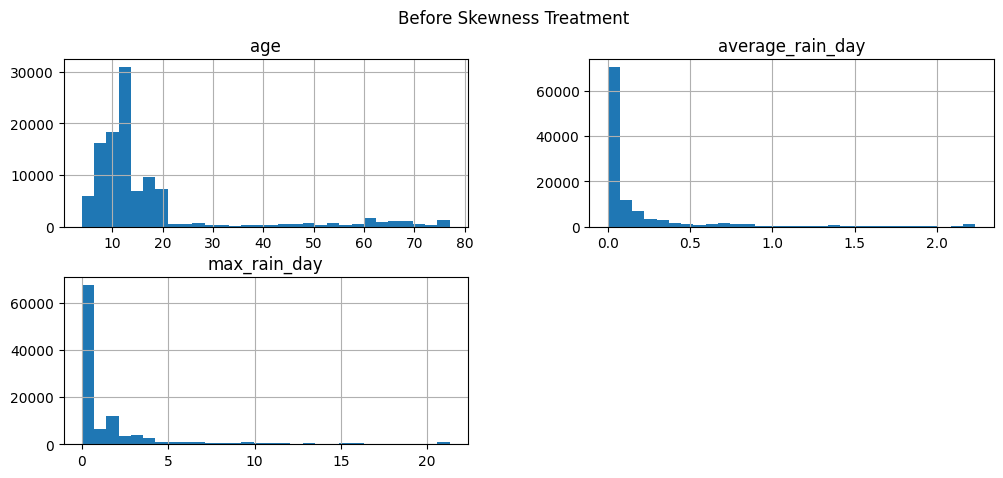

In [29]:
import matplotlib.pyplot as plt

# Columns to check
cols = [
    'age',
    'average_rain_day',
    'max_rain_day'
]

# Plot histogram
df[cols].hist(
    figsize=(12,5),
    bins=30
)

plt.suptitle(
    "Before Skewness Treatment"
)

plt.show()

In [34]:

from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(
    method='yeo-johnson'
)

df[['average_rain_day']] = pt.fit_transform(
    df[['average_rain_day']]
)

In [35]:
print(df[
    [
        'age',
        'average_rain_day',
        'max_rain_day'
    ]
].skew())

age                 0.859142
average_rain_day    0.715367
max_rain_day        0.814993
dtype: float64


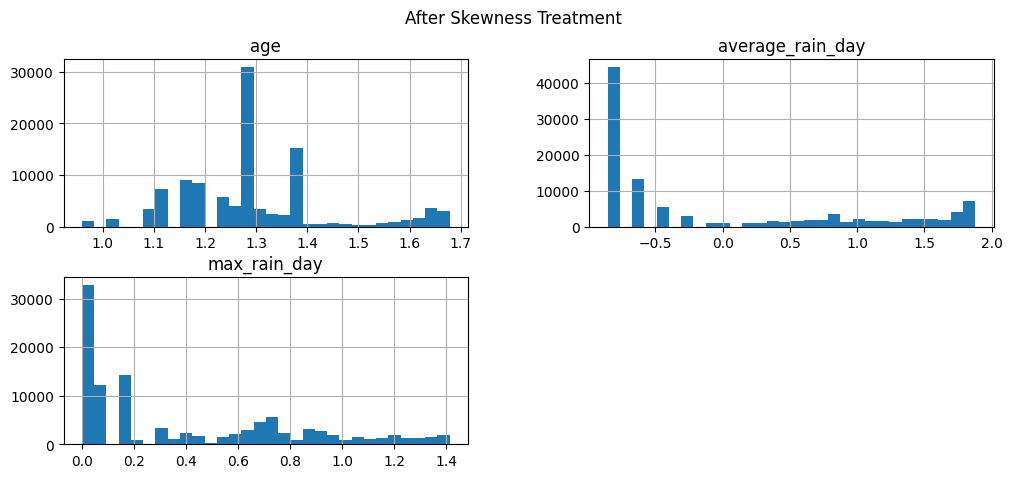

In [36]:
df[cols].hist(
    figsize=(12,5),
    bins=30
)

plt.suptitle(
    "After Skewness Treatment"
)

plt.show()

In [37]:
from sklearn.preprocessing import StandardScaler

scale_cols = [
    'age',
    'average_temp_day',
    'average_rain_day',
    'max_temp_day',
    'max_rain_day'
]

scaler = StandardScaler()

df[scale_cols] = scaler.fit_transform(
    df[scale_cols]
)

In [ ]:
#Binary / Encoded Columns
# specialty
# gender
# disability
# appointment_shift
# under_12_years_old
# over_60_years_old
# patient_needs_companion
# rainy_day_before
# storm_day_before
# rain_intensity
# heat_intensity
# Hipertension
# Diabetes
# Alcoholism
# Handcap
# Scholarship
# SMS_received
# place_encoded

In [39]:
df.to_csv("../data/Scaled_data.csv")
print("data saved...")

data saved...
